# Importamos las bibliotecas y cargamos los datos

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import math

In [34]:
df = pd.read_csv("Covid-19_survey.csv", delimiter = "," ,header = 0)
# Diccionarios



In [35]:
# ciudad_dict = {31: "Concepción", 83: "Santiago"}
# ingreso_dict = {
#     1: "Menos de $300.000",
#     2: "$300.001 a $600.000",
#     3: "$600.001 a $1.000.000",
#     4: "$1.000.001 a $1.500.000",
#     5: "$1.500.001 a $2.000.000",
#     6: "$2.000.001 a $3.000.000",
#     7: "Más de $3.000.000"
# }
# nivel_educ_dict = {
#     1: "Técnico-profesional",
#     2: "Enseñanza media",
#     3: "Profesional-postgrado",
#     4: "Profesional-pregrado",
#     5: "Enseñanza básica",
#     6: "Sin estudios formales"
# }
# gen_dict = {
#     1: "Masculino",
#     2: "Femenino",
#     3: "Otro",
#     4: "Prefiero no decir"
# }
# teletra_dict = {
#     1: "Teletrabajo normal desde casa",
#     2: "En casa sin trabajar",
#     3: "Teletrabajo esporádico",
#     4: "Trabajo menos frecuentemente o turno ético",
#     5: "Debo viajar para trabajar",
#     6: "Otra",
#     7: "Trabajo presencial normal",
#     8: "Trabajo presencial con cambio de transporte"
# }
# edad_dict = {
#     1: "18-25 años",
#     2: "26-35 años",
#     3: "36-45 años",
#     4: "46-60 años",
#     5: "Más de 60 años"
# }

# # Aplicar cambios
# df['CIUDAD'] = df['CIUDAD'].replace(ciudad_dict)
# df['INGRESO'] = df['INGRESO'].replace(ingreso_dict)
# df['NIVEL_EDUC'] = df['NIVEL_EDUC'].replace(nivel_educ_dict)
# df['GEN'] = df['GEN'].replace(gen_dict)
# df['TELE_TRA'] = df['TELE_TRA'].replace(teletra_dict)
# df['EDAD'] = df['EDAD'].replace(edad_dict)

In [36]:
# Primeras filas
print(df.head())

# Dimensión del DataFrame
print("Filas y columnas:", df.shape)

# Tipos de variables y nulos
print(df.info())

# Resumen estadístico (solo numéricas)
print(df.describe())

# Conteo de valores nulos por columna
print(df.isnull().sum())

# Variable dependiente TELE_TRA
print(df['TELE_TRA'].value_counts(dropna=False))




   ID  CIUDAD  COMSTGO  COMCONCE  EMP  VTRA_S1_AUTO  VTRA_S1_BUS  \
0   1      83     35.0       NaN    6           0.0          8.5   
1   2      83     33.0       NaN    6           0.0          0.0   
2   3      83     47.0       NaN    8           0.0          0.0   
3   4      83     38.0       NaN    6           2.0          2.0   
4   5      83     47.0       NaN    6           0.0          8.5   

   VTRA_S1_METRO  VTRA_S1_TAXI  VTRA_S1_COL  ...  PROB_EMI  PROB_SOLI  \
0            8.5           2.0          0.0  ...         3          3   
1            0.0           0.0          0.0  ...         2          2   
2            0.0           0.0          0.0  ...         2          3   
3            2.0           2.0         12.0  ...         3          1   
4            2.0           0.0          0.0  ...         4          4   

   PROB_PLANET  EDAD  HHSIZE  NVEH  LICEN  NIVEL_EDUC  GEN  INGRESO  
0            3     4       5     2      1           3    2        7  
1           

In [37]:
print(df.isnull().sum())

ID               0
CIUDAD           0
COMSTGO        212
COMCONCE      2088
EMP              0
              ... 
NVEH             0
LICEN            0
NIVEL_EDUC       0
GEN              0
INGRESO          0
Length: 120, dtype: int64


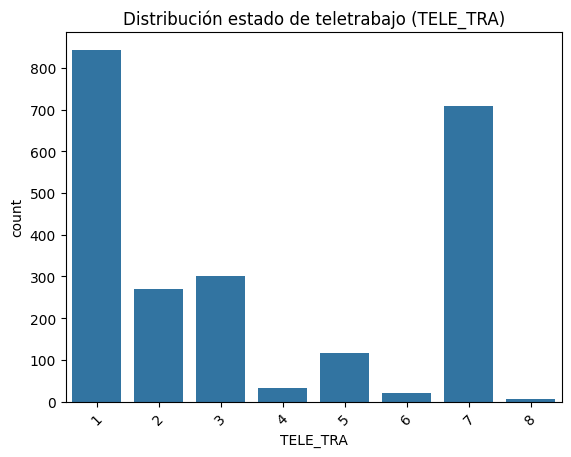

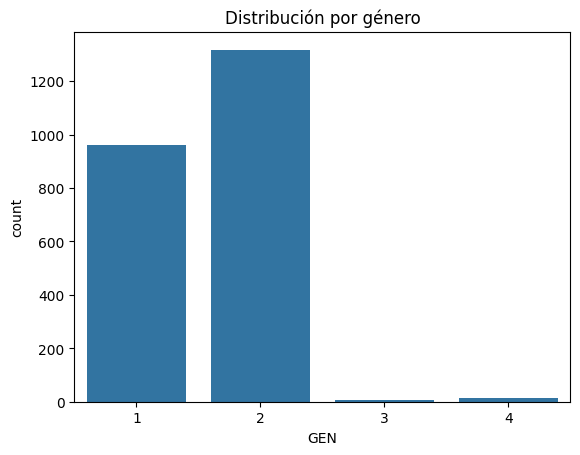

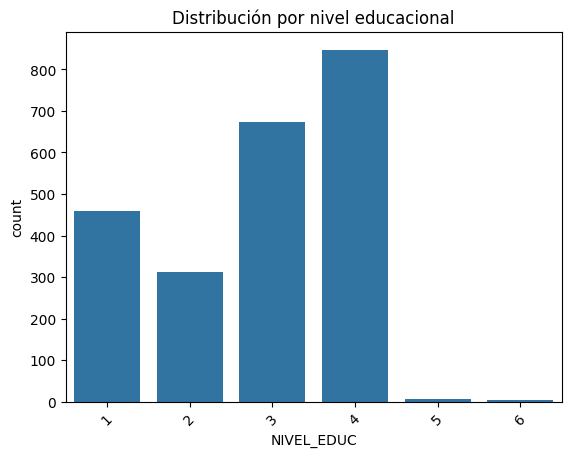

In [38]:

# Teletrabajo
sns.countplot(data=df, x='TELE_TRA')
plt.title('Distribución estado de teletrabajo (TELE_TRA)')
plt.xticks(rotation=45)
plt.show()

# Género
sns.countplot(data=df, x='GEN')
plt.title('Distribución por género')
plt.show()

# Nivel educacional
sns.countplot(data=df, x='NIVEL_EDUC')
plt.title('Distribución por nivel educacional')
plt.xticks(rotation=45)
plt.show()



In [39]:
# Tabla resumen para Excel: ejemplo con TELE_TRA
teletra_counts = df['TELE_TRA'].value_counts(dropna=False)
teletra_perc = df['TELE_TRA'].value_counts(normalize=True, dropna=False) * 100

tabla_teletra = pd.DataFrame({
    'Frecuencia': teletra_counts,
    'Porcentaje': teletra_perc.round(2)
})

print(tabla_teletra)


          Frecuencia  Porcentaje
TELE_TRA                        
1                844       36.70
7                708       30.78
3                301       13.09
2                271       11.78
5                117        5.09
4                 32        1.39
6                 21        0.91
8                  6        0.26


In [40]:
# Teletrabajo por género
tabla_teletrabajo_genero = pd.crosstab(df['TELE_TRA'], df['GEN'], margins=True)
print("Teletrabajo por género:")
print(tabla_teletrabajo_genero)
print("\n")

# Teletrabajo por nivel educacional
tabla_teletrabajo_educ = pd.crosstab(df['TELE_TRA'], df['NIVEL_EDUC'], margins=True)
print("Teletrabajo por nivel educacional:")
print(tabla_teletrabajo_educ)
print("\n")

# Teletrabajo por ingreso
tabla_teletrabajo_ingreso = pd.crosstab(df['TELE_TRA'], df['INGRESO'], margins=True)
print("Teletrabajo por ingreso:")
print(tabla_teletrabajo_ingreso)
print("\n")

# Teletrabajo por ciudad
tabla_teletrabajo_ciudad = pd.crosstab(df['TELE_TRA'], df['CIUDAD'], margins=True)
print("Teletrabajo por ciudad:")
print(tabla_teletrabajo_ciudad)
print("\n")


Teletrabajo por género:
GEN         1     2  3   4   All
TELE_TRA                        
1         370   468  2   4   844
2          70   196  3   2   271
3          85   215  0   1   301
4          10    22  0   0    32
5          63    51  0   3   117
6           5    16  0   0    21
7         355   347  1   5   708
8           3     3  0   0     6
All       961  1318  6  15  2300


Teletrabajo por nivel educacional:
NIVEL_EDUC    1    2    3    4  5  6   All
TELE_TRA                                  
1            79   26  352  387  0  0   844
2            63   66   48   94  0  0   271
3            41    9  132  118  0  1   301
4             7    5    6   14  0  0    32
5            31   35   18   32  0  1   117
6             4    3    5    9  0  0    21
7           234  167  110  190  6  1   708
8             0    0    2    4  0  0     6
All         459  311  673  848  6  3  2300


Teletrabajo por ingreso:
INGRESO     1    2    3    4    5    6    7   All
TELE_TRA                  

In [41]:
# Variable binaria: 1 = teletrabajo normal/esporádico, 0 = resto
df['TELE_BIN'] = df['TELE_TRA'].isin([1,3]).astype(int)

# Teletrabajo binario por género
tabla_bin_genero = pd.crosstab(df['TELE_BIN'], df['GEN'], margins=True)
print("Teletrabajo binario por género:")
print(tabla_bin_genero)
print("\n")

# Teletrabajo binario por nivel educacional
tabla_bin_educ = pd.crosstab(df['TELE_BIN'], df['NIVEL_EDUC'], margins=True)
print("Teletrabajo binario por nivel educacional:")
print(tabla_bin_educ)
print("\n")

# Teletrabajo binario por ingreso
tabla_bin_ingreso = pd.crosstab(df['TELE_BIN'], df['INGRESO'], margins=True)
print("Teletrabajo binario por ingreso:")
print(tabla_bin_ingreso)
print("\n")

# Teletrabajo binario por ciudad
tabla_bin_ciudad = pd.crosstab(df['TELE_BIN'], df['CIUDAD'], margins=True)
print("Teletrabajo binario por ciudad:")
print(tabla_bin_ciudad)
print("\n")


Teletrabajo binario por género:
GEN         1     2  3   4   All
TELE_BIN                        
0         506   635  4  10  1155
1         455   683  2   5  1145
All       961  1318  6  15  2300


Teletrabajo binario por nivel educacional:
NIVEL_EDUC    1    2    3    4  5  6   All
TELE_BIN                                  
0           339  276  189  343  6  2  1155
1           120   35  484  505  0  1  1145
All         459  311  673  848  6  3  2300


Teletrabajo binario por ingreso:
INGRESO     1    2    3    4    5    6    7   All
TELE_BIN                                         
0          90  405  248  153   86   82   91  1155
1          15   97  163  198  189  208  275  1145
All       105  502  411  351  275  290  366  2300


Teletrabajo binario por ciudad:
CIUDAD     31    83   All
TELE_BIN                 
0          74  1081  1155
1         138  1007  1145
All       212  2088  2300




In [42]:
print("Distribución por edad:")
print(df['EDAD'].value_counts().sort_index())
print("\n")

print("Distribución del tamaño del hogar:")
print(df['HHSIZE'].describe())
print("\n")

print("Distribución por ingreso:")
print(df['INGRESO'].value_counts().sort_index())
print("\n")


Distribución por edad:
EDAD
1    275
2    900
3    642
4    390
5     93
Name: count, dtype: int64


Distribución del tamaño del hogar:
count    2300.000000
mean        3.408696
std         1.679369
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: HHSIZE, dtype: float64


Distribución por ingreso:
INGRESO
1    105
2    502
3    411
4    351
5    275
6    290
7    366
Name: count, dtype: int64




Gráfico: Teletrabajo por género


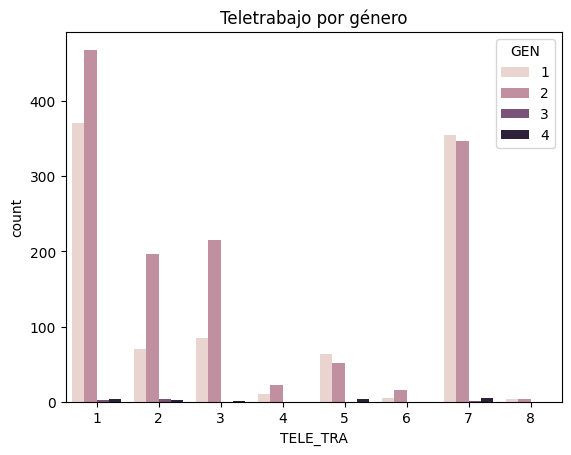

Gráfico: Teletrabajo por nivel educacional


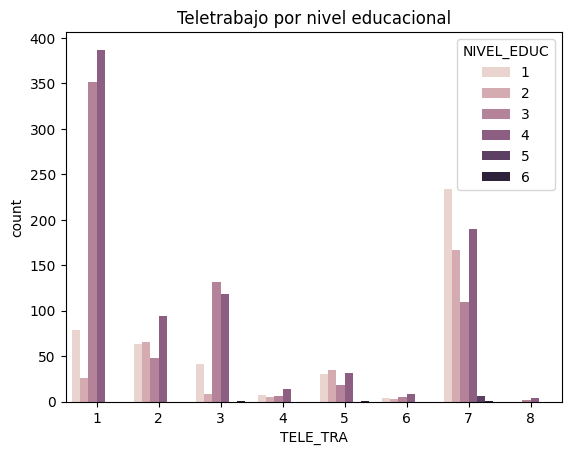

Gráfico: Teletrabajo por ingreso


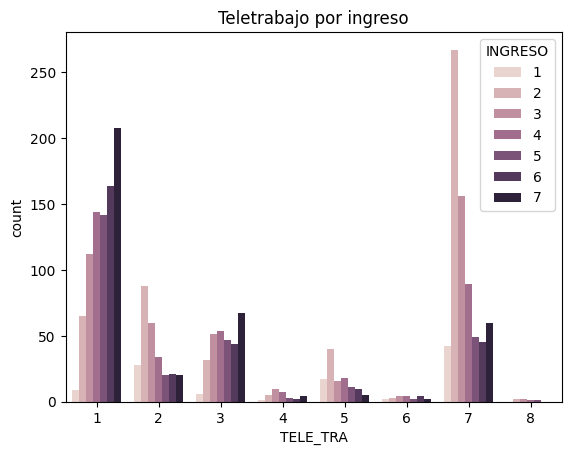

Gráfico: Teletrabajo por ciudad


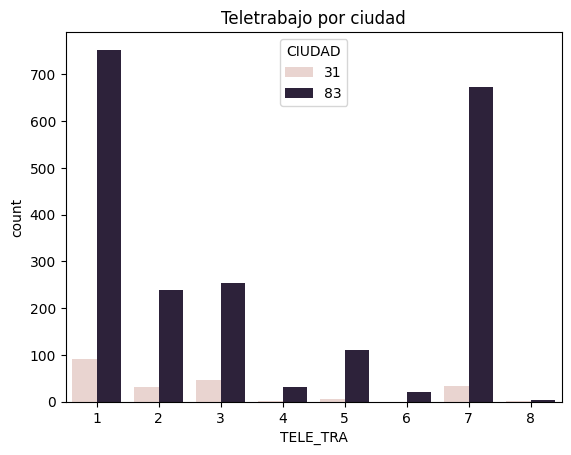

In [43]:

print("Gráfico: Teletrabajo por género")
sns.countplot(data=df, x='TELE_TRA', hue='GEN')
plt.title('Teletrabajo por género')
plt.show()

print("Gráfico: Teletrabajo por nivel educacional")
sns.countplot(data=df, x='TELE_TRA', hue='NIVEL_EDUC')
plt.title('Teletrabajo por nivel educacional')
plt.show()

print("Gráfico: Teletrabajo por ingreso")
sns.countplot(data=df, x='TELE_TRA', hue='INGRESO')
plt.title('Teletrabajo por ingreso')
plt.show()

print("Gráfico: Teletrabajo por ciudad")
sns.countplot(data=df, x='TELE_TRA', hue='CIUDAD')
plt.title('Teletrabajo por ciudad')
plt.show()


In [44]:
print("Uso de auto antes y después de la pandemia:")
print(df[['VTRA_S1_AUTO', 'VTRA_S2_AUTO']].describe())
print("\n")

print("Uso de bus antes y después de la pandemia:")
print(df[['VTRA_S1_BUS', 'VTRA_S2_BUS']].describe())
print("\n")

print("Uso de metro antes y después de la pandemia:")
print(df[['VTRA_S1_METRO', 'VTRA_S2_METRO']].describe())
print("\n")


Uso de auto antes y después de la pandemia:
       VTRA_S1_AUTO  VTRA_S2_AUTO
count   2300.000000   2300.000000
mean       2.715652      1.743261
std        3.961759      2.983618
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        5.000000      2.000000
max       12.000000     12.000000


Uso de bus antes y después de la pandemia:
       VTRA_S1_BUS  VTRA_S2_BUS
count  2300.000000  2300.000000
mean      3.613913     2.177391
std       4.388370     3.659265
min       0.000000     0.000000
25%       0.000000     0.000000
50%       2.000000     0.000000
75%       8.500000     2.000000
max      12.000000    12.000000


Uso de metro antes y después de la pandemia:
       VTRA_S1_METRO  VTRA_S2_METRO
count    2300.000000    2300.000000
mean        3.346304       1.706957
std         4.176115       3.235534
min         0.000000       0.000000
25%         0.000000       0.000000
50%         2.000000       0.000000
75%         5.0000

In [45]:
print("Distribución de la preocupación por ingreso:")
print(df['PREO_INGRESO'].value_counts().sort_index())
print("\n")

print("Distribución de la probabilidad de poder teletrabajar:")
print(df['PROB_TELETR'].value_counts().sort_index())
print("\n")


Distribución de la preocupación por ingreso:
PREO_INGRESO
1     126
2     161
3     391
4     337
5    1285
Name: count, dtype: int64


Distribución de la probabilidad de poder teletrabajar:
PROB_TELETR
1    280
2    412
3    645
4    592
5    371
Name: count, dtype: int64




In [46]:
# Personas con hijos en el hogar vs teletrabajo
df['HIJOS'] = ((df['SITU_HOGAR_1'] == 1) | (df['SITU_HOGAR_2'] == 1) | (df['SITU_HOGAR_3'] == 1) | (df['SITU_HOGAR_4'] == 1)).astype(int)
print(pd.crosstab(df['TELE_TRA'], df['HIJOS'], margins=True))

# Personas con adultos mayores en el hogar
print(pd.crosstab(df['TELE_TRA'], df['SITU_HOGAR_5'], margins=True))

HIJOS        0    1   All
TELE_TRA                 
1          514  330   844
2          162  109   271
3          152  149   301
4           17   15    32
5           59   58   117
6           11   10    21
7          405  303   708
8            4    2     6
All       1324  976  2300
SITU_HOGAR_5     0    1   All
TELE_TRA                     
1              661  183   844
2              180   91   271
3              236   65   301
4               23    9    32
5               83   34   117
6               15    6    21
7              542  166   708
8                4    2     6
All           1744  556  2300


In [47]:
# Promedio de preocupación por ingreso según teletrabajo
print(df.groupby('TELE_TRA')['PREO_INGRESO'].mean())

# Tabla de frecuencia cruzada
df['PREO_INGRESO_CAT'] = pd.cut(df['PREO_INGRESO'], bins=[0,2,3,5], labels=["Baja", "Media", "Alta"])
print(pd.crosstab(df['TELE_TRA'], df['PREO_INGRESO_CAT'], margins=True))

TELE_TRA
1    3.844787
2    4.357934
3    3.873754
4    3.937500
5    4.615385
6    4.047619
7    4.272599
8    4.333333
Name: PREO_INGRESO, dtype: float64
PREO_INGRESO_CAT  Baja  Media  Alta   All
TELE_TRA                                 
1                  148    162   534   844
2                   18     39   214   271
3                   48     63   190   301
4                    6      5    21    32
5                    0     17   100   117
6                    3      3    15    21
7                   63    102   543   708
8                    1      0     5     6
All                287    391  1622  2300


In [48]:
# Diagnóstico COVID por teletrabajo
print(pd.crosstab(df['TELE_TRA'], df['DIAG_COVID'], margins=True))

# Contacto estrecho COVID por teletrabajo
print(pd.crosstab(df['TELE_TRA'], df['CONTACT_COVID'], margins=True))


DIAG_COVID     0  1   All
TELE_TRA                 
1            843  1   844
2            271  0   271
3            301  0   301
4             32  0    32
5            117  0   117
6             21  0    21
7            705  3   708
8              6  0     6
All         2296  4  2300
CONTACT_COVID     0   1   All
TELE_TRA                     
1               812  32   844
2               266   5   271
3               287  14   301
4                31   1    32
5               116   1   117
6                20   1    21
7               674  34   708
8                 6   0     6
All            2212  88  2300


In [49]:
# Cambio en viajes en auto, bus, metro antes y después
df['CAMBIO_AUTO'] = df['VTRA_S2_AUTO'] - df['VTRA_S1_AUTO']
df['CAMBIO_BUS'] = df['VTRA_S2_BUS'] - df['VTRA_S1_BUS']
df['CAMBIO_METRO'] = df['VTRA_S2_METRO'] - df['VTRA_S1_METRO']

print("Cambio promedio de viajes en AUTO:", df['CAMBIO_AUTO'].mean())
print("Cambio promedio de viajes en BUS:", df['CAMBIO_BUS'].mean())
print("Cambio promedio de viajes en METRO:", df['CAMBIO_METRO'].mean())

# Por grupo de teletrabajo
print(df.groupby('TELE_TRA')[['CAMBIO_AUTO', 'CAMBIO_BUS', 'CAMBIO_METRO']].mean())


Cambio promedio de viajes en AUTO: -0.9723913043478261
Cambio promedio de viajes en BUS: -1.4365217391304348
Cambio promedio de viajes en METRO: -1.6393478260869565
          CAMBIO_AUTO  CAMBIO_BUS  CAMBIO_METRO
TELE_TRA                                       
1           -1.504739   -1.672393     -2.366706
2           -1.464945   -2.490775     -1.717712
3           -2.214286   -1.936877     -1.855482
4            0.750000   -1.750000     -1.375000
5           -0.243590   -1.076923     -1.209402
6           -1.357143   -0.595238     -1.142857
7            0.185734   -0.605226     -0.740819
8           -0.250000   -1.916667     -2.500000


In [50]:
# Opinión sobre las medidas del gobierno vs teletrabajo
print(pd.crosstab(df['TELE_TRA'], df['MED_GOB'], margins=True))

# Percepción de probabilidad de teletrabajo vs teletrabajo real
print(df.groupby('TELE_TRA')['PROB_TELETR'].mean())


MED_GOB    0    1  2     3   All
TELE_TRA                        
1          8  115  3   718   844
2          2   22  0   247   271
3          4   44  1   252   301
4          1    8  0    23    32
5          3   13  2    99   117
6          1    1  0    19    21
7          9   63  1   635   708
8          0    0  0     6     6
All       28  266  7  1999  2300
TELE_TRA
1    3.482227
2    2.915129
3    3.196013
4    3.343750
5    2.820513
6    3.190476
7    2.882768
8    4.333333
Name: PROB_TELETR, dtype: float64


In [51]:
# ¿Tener más autos facilita el teletrabajo?
print(pd.crosstab(df['TELE_TRA'], df['NVEH'], margins=True))


NVEH        0     1    2   3   All
TELE_TRA                          
1         267   382  166  29   844
2         102   109   44  16   271
3          75   148   63  15   301
4           8    17    3   4    32
5          45    49   20   3   117
6           7     8    5   1    21
7         322   291   79  16   708
8           2     4    0   0     6
All       828  1008  380  84  2300


In [52]:
# Uso de transporte público por género
print(df.groupby('GEN')[['VTRA_S1_BUS', 'VTRA_S2_BUS', 'VTRA_S1_METRO', 'VTRA_S2_METRO']].mean())


     VTRA_S1_BUS  VTRA_S2_BUS  VTRA_S1_METRO  VTRA_S2_METRO
GEN                                                        
1       3.825182     2.626951       3.556191       1.960978
2       3.429059     1.820182       3.174886       1.481411
3       4.916667     2.000000       1.500000       0.833333
4       5.800000     4.833333       5.700000       5.600000


In [53]:
print(pd.crosstab(df['TELE_TRA'], df['LICEN'], margins=True))


LICEN       0     1   All
TELE_TRA                 
1         254   590   844
2         152   119   271
3          92   209   301
4          10    22    32
5          59    58   117
6           7    14    21
7         371   337   708
8           2     4     6
All       947  1353  2300


In [54]:
# ¿Quiénes reportan máxima preocupación por empleo?
# max_preocupacion = df[df['PREO_EMPLEO'] == 5]
# print("Personas con máxima preocupación por empleo, por tipo de trabajo:")
# print(max_preocupacion['TELE_TRA'].value_counts())


In [55]:
# ¿Quiénes se comunican por video/voz/texto con familiares, amigos, etc.?
com_cols = [col for col in df.columns if 'COM_S2' in col and ('TEX' in col or 'VID' in col or 'VOZ' in col)]
df['COM_TOTAL'] = df[com_cols].sum(axis=1)
print("Comunicación digital total por tipo de trabajo:")
print(df.groupby('TELE_TRA')['COM_TOTAL'].mean())

Comunicación digital total por tipo de trabajo:
TELE_TRA
1    6.768957
2    5.723247
3    6.813953
4    6.218750
5    6.051282
6    6.000000
7    5.707627
8    6.333333
Name: COM_TOTAL, dtype: float64


In [56]:
# Cruzar Teletrabajo, Género y Ciudad
tabla = pd.crosstab([df['CIUDAD'], df['GEN']], df['TELE_TRA'], margins=True)
print(tabla)


TELE_TRA      1    2    3   4    5   6    7  8   All
CIUDAD GEN                                          
31     1     36    6   14   1    3   0   17  1    78
       2     53   23   33   0    3   0   17  1   130
       3      0    2    0   0    0   0    0  0     2
       4      2    0    0   0    0   0    0  0     2
83     1    334   64   71   9   60   5  338  2   883
       2    415  173  182  22   48  16  330  2  1188
       3      2    1    0   0    0   0    1  0     4
       4      2    2    1   0    3   0    5  0    13
All         844  271  301  32  117  21  708  6  2300


In [57]:
# Cruzar Teletrabajo y Rango de Edad
tabla = pd.crosstab(df['EDAD'], df['TELE_TRA'], margins=True)
print(tabla)


TELE_TRA    1    2    3   4    5   6    7  8   All
EDAD                                              
1          53   47   19   2   25   3  126  0   275
2         354  102  104   7   41   5  283  4   900
3         259   59  106  14   28   7  168  1   642
4         139   48   55   8   19   4  116  1   390
5          39   15   17   1    4   2   15  0    93
All       844  271  301  32  117  21  708  6  2300


In [58]:
# Cambio de viajes en BUS por Nivel Educacional
df['CAMBIO_BUS'] = df['VTRA_S2_BUS'] - df['VTRA_S1_BUS']
cambio_educ = df.groupby('NIVEL_EDUC')['CAMBIO_BUS'].mean()
print("Cambio promedio de viajes en BUS por Nivel Educacional:")
print(cambio_educ)


Cambio promedio de viajes en BUS por Nivel Educacional:
NIVEL_EDUC
1   -1.309368
2   -1.255627
3   -1.217682
4   -1.764151
5    0.500000
6    0.000000
Name: CAMBIO_BUS, dtype: float64


In [59]:
# Promedio de preocupación por ingreso según posibilidad de teletrabajo
prom_preocupacion = df.groupby('TELE_TRA')['PREO_INGRESO'].mean()
print("Promedio de preocupación por ingreso según estado de teletrabajo:")
print(prom_preocupacion)


Promedio de preocupación por ingreso según estado de teletrabajo:
TELE_TRA
1    3.844787
2    4.357934
3    3.873754
4    3.937500
5    4.615385
6    4.047619
7    4.272599
8    4.333333
Name: PREO_INGRESO, dtype: float64


In [60]:
# Tamaño de hogar promedio según estado de teletrabajo
tamano_hogar = df.groupby('TELE_TRA')['HHSIZE'].mean()
print("Tamaño del hogar promedio según estado de teletrabajo:")
print(tamano_hogar)


Tamaño del hogar promedio según estado de teletrabajo:
TELE_TRA
1    3.074645
2    3.623616
3    3.275748
4    3.531250
5    4.162393
6    2.809524
7    3.665254
8    3.833333
Name: HHSIZE, dtype: float64


In [61]:
# 1. Estado de teletrabajo (ya la tienes como 'tabla_teletra')
teletra_counts = df['TELE_TRA'].value_counts(dropna=False)
teletra_perc = df['TELE_TRA'].value_counts(normalize=True, dropna=False) * 100
tabla_teletra = pd.DataFrame({
    'Frecuencia': teletra_counts,
    'Porcentaje': teletra_perc.round(2)
})

# 2. Teletrabajo por género
tabla_teletrabajo_genero = pd.crosstab(df['TELE_TRA'], df['GEN'], margins=True)

# 3. Teletrabajo por nivel educacional
tabla_teletrabajo_educ = pd.crosstab(df['TELE_TRA'], df['NIVEL_EDUC'], margins=True)

# 4. Teletrabajo por ingreso
tabla_teletrabajo_ingreso = pd.crosstab(df['TELE_TRA'], df['INGRESO'], margins=True)

# 5. Teletrabajo por ciudad
tabla_teletrabajo_ciudad = pd.crosstab(df['TELE_TRA'], df['CIUDAD'], margins=True)

# 6. Teletrabajo por edad
tabla_teletrabajo_edad = pd.crosstab(df['EDAD'], df['TELE_TRA'], margins=True)

# 7. Preocupación económica según teletrabajo
preocupacion_tabla = df.groupby('TELE_TRA')['PREO_INGRESO'].mean().round(2)
preocupacion_tabla = pd.DataFrame(preocupacion_tabla)
preocupacion_tabla.columns = ['Promedio Preocupación Ingreso']

# 8. Cambio en movilidad según nivel educacional
df['CAMBIO_BUS'] = df['VTRA_S2_BUS'] - df['VTRA_S1_BUS']
cambio_educ = df.groupby('NIVEL_EDUC')['CAMBIO_BUS'].mean().round(2)
cambio_educ = pd.DataFrame(cambio_educ)
cambio_educ.columns = ['Cambio Promedio Viajes Bus']

# Guardar en un solo archivo Excel
with pd.ExcelWriter("tablas_comparativas_covid.xlsx") as writer:
    tabla_teletra.to_excel(writer, sheet_name="Teletrabajo General")
    tabla_teletrabajo_genero.to_excel(writer, sheet_name="Teletrabajo por Género")
    tabla_teletrabajo_educ.to_excel(writer, sheet_name="Teletrabajo por Educ")
    tabla_teletrabajo_ingreso.to_excel(writer, sheet_name="Teletrabajo por Ingreso")
    tabla_teletrabajo_ciudad.to_excel(writer, sheet_name="Teletrabajo por Ciudad")
    tabla_teletrabajo_edad.to_excel(writer, sheet_name="Teletrabajo por Edad")
    preocupacion_tabla.to_excel(writer, sheet_name="Preocupación Económica")
    cambio_educ.to_excel(writer, sheet_name="Cambio Movilidad Bus")


                   mean       std  min  25%  50%  75%   max    % ceros
VTRA_S1_AUTO   2.715652  3.961759  0.0  0.0  0.0  5.0  12.0  54.652174
VTRA_S1_BUS    3.613913  4.388370  0.0  0.0  2.0  8.5  12.0  46.086957
VTRA_S1_METRO  3.346304  4.176115  0.0  0.0  2.0  5.0  12.0  45.956522
VTRA_S1_TAXI   0.337391  1.131460  0.0  0.0  0.0  0.0  12.0  88.217391
VTRA_S1_COL    0.397174  1.482966  0.0  0.0  0.0  0.0  12.0  89.739130
VTRA_S1_BIC    0.908261  2.615920  0.0  0.0  0.0  0.0  12.0  85.086957
VTRA_S1_CAM    3.025870  4.028104  0.0  0.0  2.0  5.0  12.0  48.217391
VTRA_S1_UBER   0.934565  1.882002  0.0  0.0  0.0  2.0  12.0  70.173913
VTRA_S1_MOTO   0.165435  1.171709  0.0  0.0  0.0  0.0  12.0  97.173913
VTRA_S2_AUTO   1.743261  2.983618  0.0  0.0  0.0  2.0  12.0  60.782609
VTRA_S2_BUS    2.177391  3.659265  0.0  0.0  0.0  2.0  12.0  61.956522
VTRA_S2_METRO  1.706957  3.235534  0.0  0.0  0.0  2.0  12.0  66.782609
VTRA_S2_TAXI   0.188913  0.865753  0.0  0.0  0.0  0.0  12.0  92.913043
VTRA_S

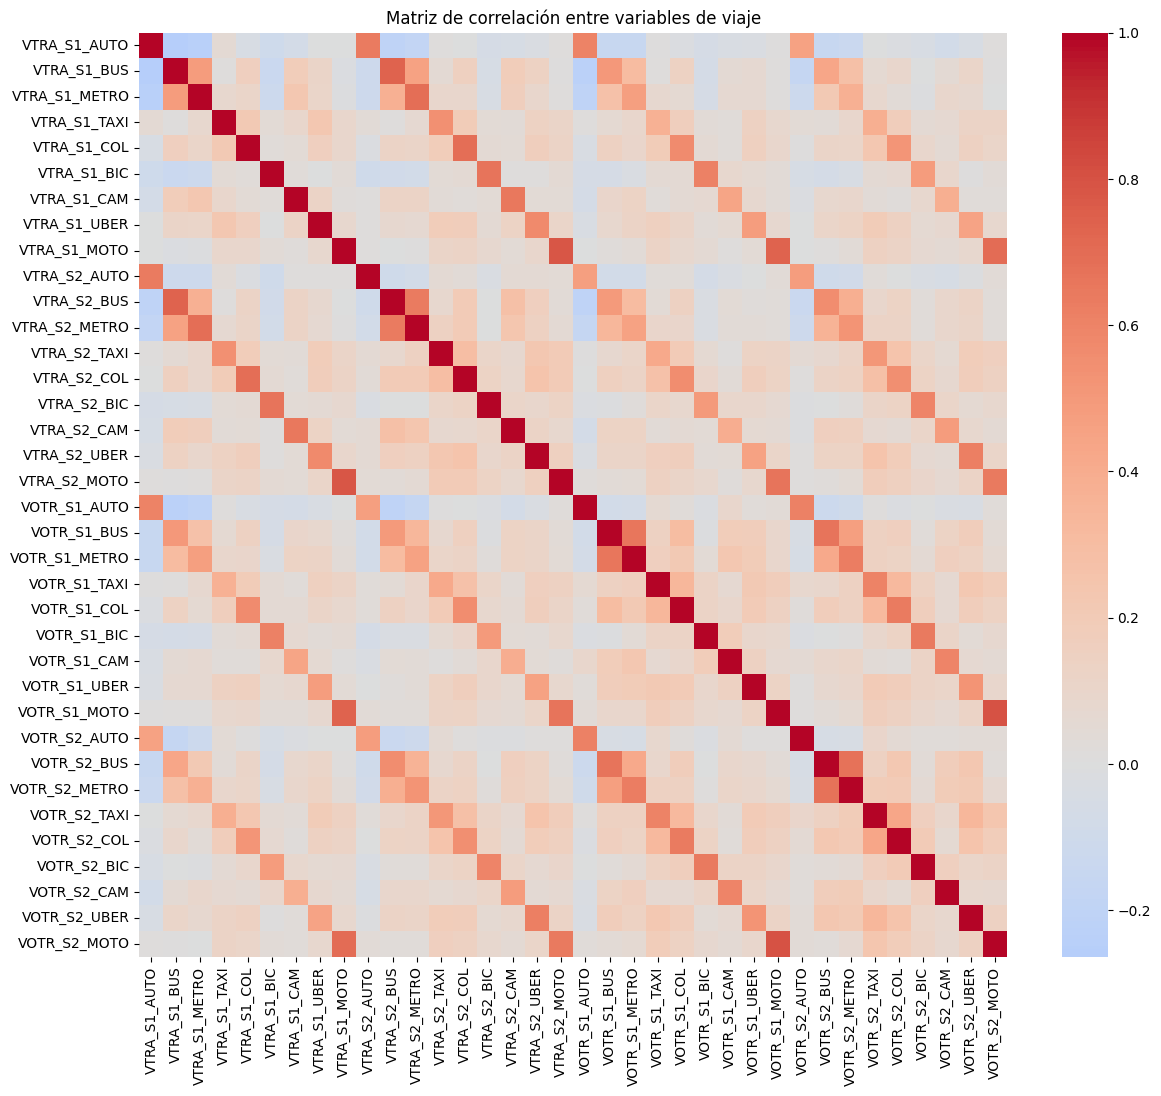

VTRA_S2_BUS     -0.413366
VTRA_S2_METRO   -0.305365
VOTR_S2_BUS     -0.283920
VTRA_S1_BUS     -0.275381
VOTR_S1_BUS     -0.265404
VOTR_S2_METRO   -0.224669
VTRA_S2_CAM     -0.168868
VOTR_S1_METRO   -0.163877
VTRA_S2_COL     -0.143107
VTRA_S2_UBER    -0.138704
VTRA_S2_AUTO    -0.122882
VOTR_S1_COL     -0.101385
VOTR_S2_COL     -0.099714
VOTR_S2_UBER    -0.096569
VTRA_S1_METRO   -0.095184
VTRA_S2_MOTO    -0.088269
VTRA_S1_COL     -0.081679
VTRA_S2_TAXI    -0.070631
VOTR_S2_TAXI    -0.059537
VTRA_S2_BIC     -0.054902
VTRA_S1_UBER    -0.046713
VOTR_S1_MOTO    -0.035739
VTRA_S1_MOTO    -0.029264
VOTR_S2_MOTO    -0.027776
VOTR_S2_CAM     -0.027038
VOTR_S2_BIC     -0.023261
VOTR_S1_UBER    -0.016805
VOTR_S1_TAXI    -0.013889
VTRA_S1_CAM      0.001701
VTRA_S1_TAXI     0.016671
VOTR_S1_CAM      0.022663
VOTR_S2_AUTO     0.023187
VOTR_S1_BIC      0.055631
VOTR_S1_AUTO     0.083831
VTRA_S1_AUTO     0.088162
VTRA_S1_BIC      0.094773
Name: TELE_BIN, dtype: float64


In [62]:
# Paso 1: seleccionar variables de viajes
viajes_vars = [col for col in df.columns if col.startswith(('VTRA_S1_', 'VTRA_S2_', 'VOTR_S1_', 'VOTR_S2_'))]

# Paso 2: estadística descriptiva para ver sparsidad
viajes_summary = df[viajes_vars].describe().T
viajes_summary['% ceros'] = (df[viajes_vars] == 0).sum() / df.shape[0] * 100
viajes_summary = viajes_summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max', '% ceros']]
print(viajes_summary)

# Paso 3: matriz de correlación entre variables de viaje
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,12))
sns.heatmap(df[viajes_vars].corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables de viaje")
plt.show()

# Paso 4: correlación con variable dependiente (si codificaste TELE_TRA binario o numérico)
# Ejemplo si creaste TELE_BIN como en el notebook
cor_with_tele = df[viajes_vars + ['TELE_BIN']].corr()['TELE_BIN'].drop('TELE_BIN')
print(cor_with_tele.sort_values())


In [63]:
# Lista de variables con más del 80% de ceros
vars_mas_80_ceros = df_graf[df_graf['% ceros'] > 80]['Variable'].tolist()

print("Variables con más del 80% de ceros:")
vars_mas_80_ceros


Variables con más del 80% de ceros:


['VTRA_S1_TAXI',
 'VTRA_S1_COL',
 'VTRA_S1_BIC',
 'VTRA_S1_MOTO',
 'VTRA_S2_TAXI',
 'VTRA_S2_COL',
 'VTRA_S2_BIC',
 'VTRA_S2_UBER',
 'VTRA_S2_MOTO',
 'VOTR_S1_TAXI',
 'VOTR_S1_COL',
 'VOTR_S1_BIC',
 'VOTR_S1_MOTO',
 'VOTR_S2_METRO',
 'VOTR_S2_TAXI',
 'VOTR_S2_COL',
 'VOTR_S2_BIC',
 'VOTR_S2_UBER',
 'VOTR_S2_MOTO']

C:\Users\alanw\AppData\Local\Temp\ipykernel_5288\659529545.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, y='Variable', x='% ceros', palette='coolwarm', ax=axes[i])
C:\Users\alanw\AppData\Local\Temp\ipykernel_5288\659529545.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, y='Variable', x='% ceros', palette='coolwarm', ax=axes[i])
C:\Users\alanw\AppData\Local\Temp\ipykernel_5288\659529545.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, y='Variable', x='% ceros', palette='coolwarm', ax=axes

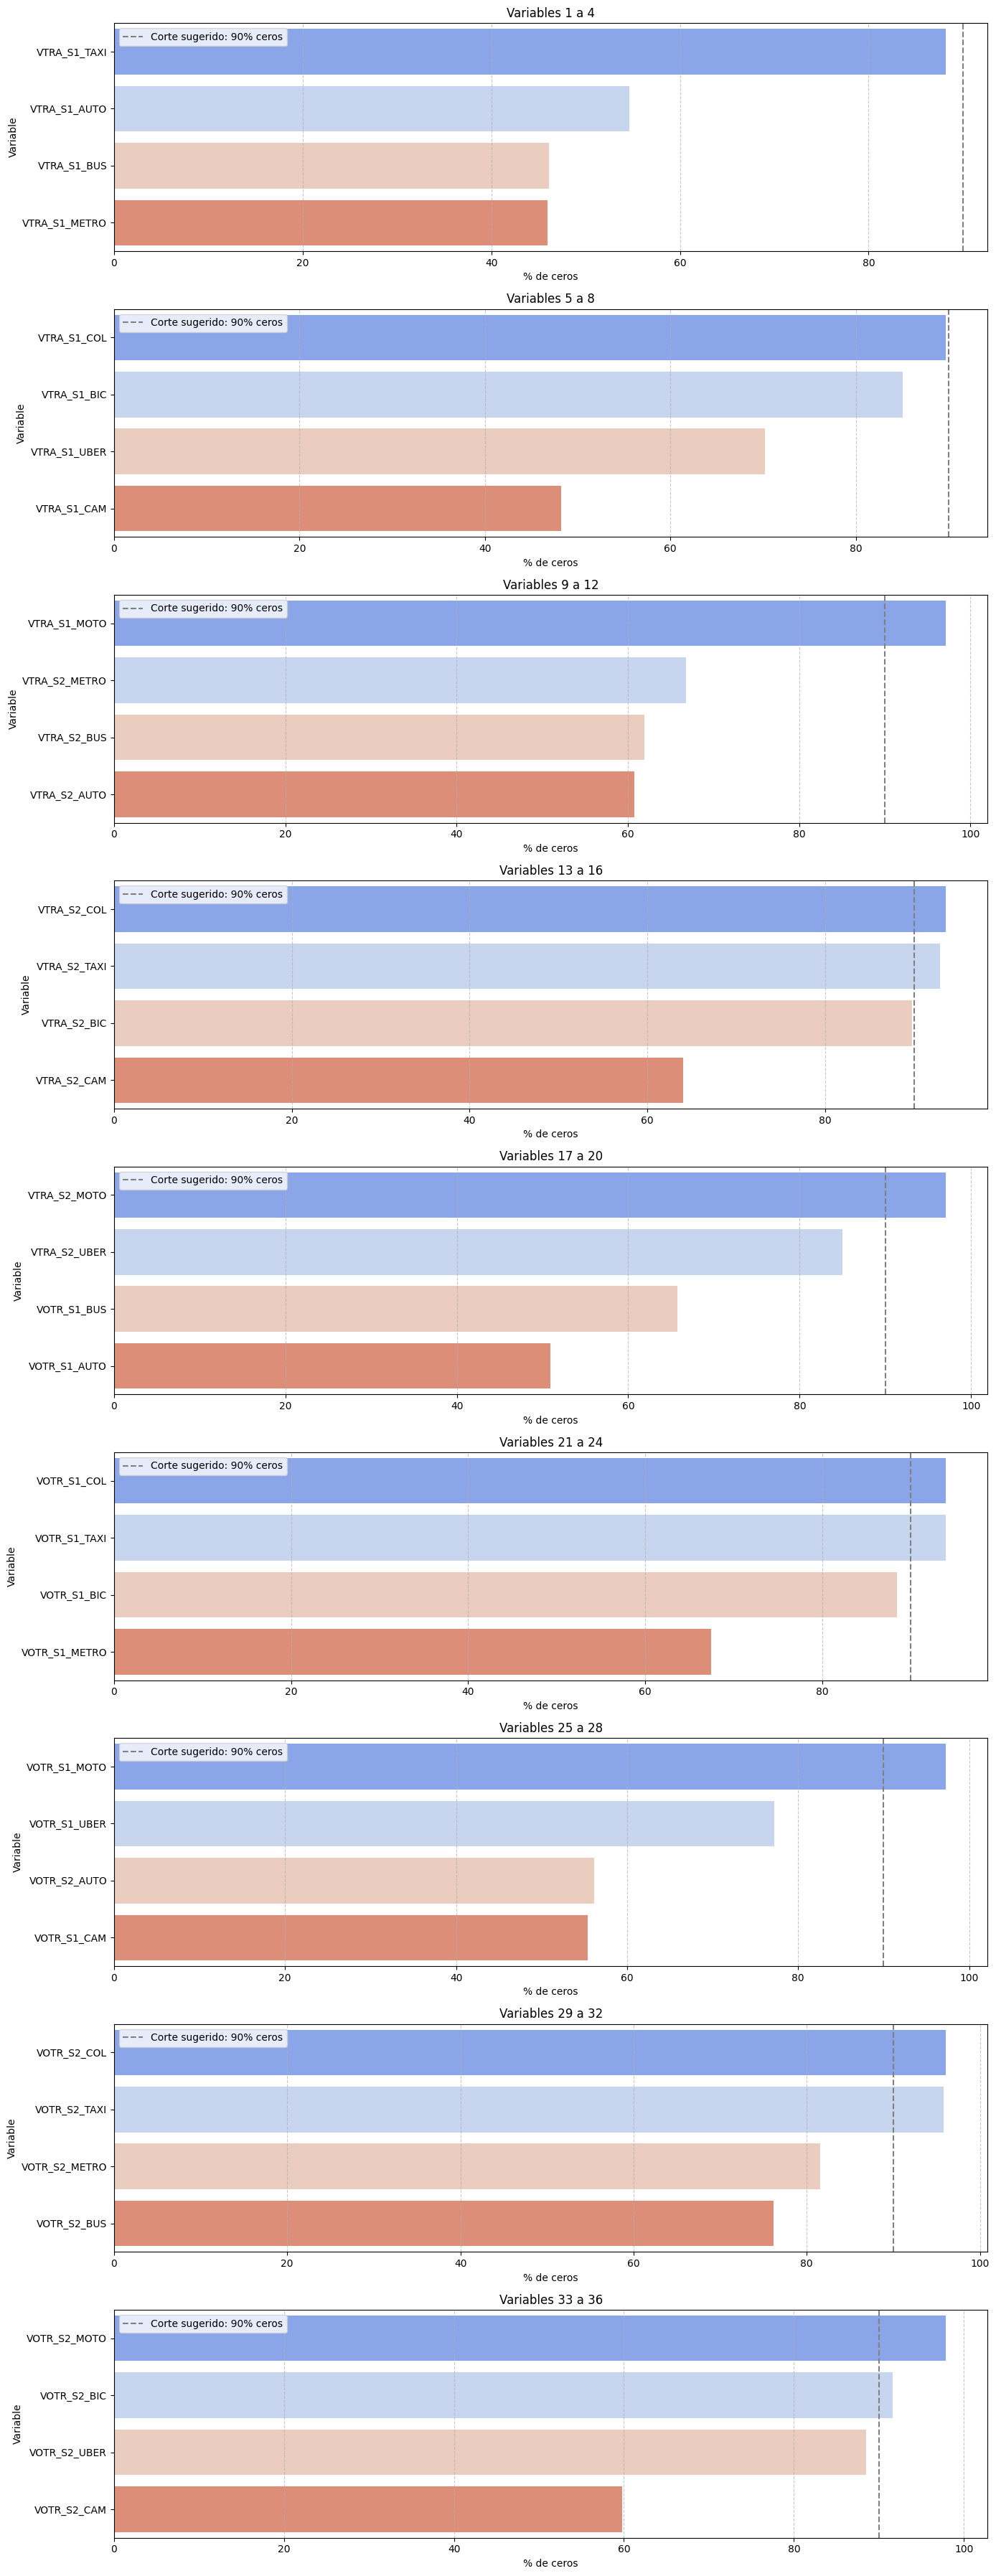

In [64]:
# Crear el DataFrame manualmente
data = {
    'Variable': [
        'VTRA_S1_AUTO', 'VTRA_S1_BUS', 'VTRA_S1_METRO', 'VTRA_S1_TAXI', 'VTRA_S1_COL', 'VTRA_S1_BIC', 'VTRA_S1_CAM',
        'VTRA_S1_UBER', 'VTRA_S1_MOTO', 'VTRA_S2_AUTO', 'VTRA_S2_BUS', 'VTRA_S2_METRO', 'VTRA_S2_TAXI',
        'VTRA_S2_COL', 'VTRA_S2_BIC', 'VTRA_S2_CAM', 'VTRA_S2_UBER', 'VTRA_S2_MOTO', 'VOTR_S1_AUTO', 'VOTR_S1_BUS',
        'VOTR_S1_METRO', 'VOTR_S1_TAXI', 'VOTR_S1_COL', 'VOTR_S1_BIC', 'VOTR_S1_CAM', 'VOTR_S1_UBER', 'VOTR_S1_MOTO',
        'VOTR_S2_AUTO', 'VOTR_S2_BUS', 'VOTR_S2_METRO', 'VOTR_S2_TAXI', 'VOTR_S2_COL', 'VOTR_S2_BIC', 'VOTR_S2_CAM',
        'VOTR_S2_UBER', 'VOTR_S2_MOTO'
    ],
    '% ceros': [
        54.65, 46.09, 45.96, 88.22, 89.74, 85.09, 48.22, 70.17, 97.17, 60.78, 61.96, 66.78,
        92.91, 93.61, 89.78, 64.04, 85.00, 97.09, 50.91, 65.70, 67.48, 93.96, 94.00, 88.48,
        55.43, 77.17, 97.30, 56.17, 76.13, 81.52, 95.78, 96.09, 91.65, 59.78, 88.52, 97.91
    ]
}

df_graf = pd.DataFrame(data)

# Número de subplots
n = df_graf.shape[0]
n_rows = math.ceil(n / 4)

# Crear subplots
fig, axes = plt.subplots(n_rows, 1, figsize=(14, n_rows * 4))

# Asegurarse que axes sea iterable
if n_rows == 1:
    axes = [axes]

# Graficar bloques de 4 variables por subplot
for i in range(n_rows):
    start = i * 4
    end = min(start + 4, n)
    subset = df_graf.iloc[start:end].sort_values('% ceros', ascending=False)
    
    sns.barplot(data=subset, y='Variable', x='% ceros', palette='coolwarm', ax=axes[i])
    axes[i].axvline(x=90, color='gray', linestyle='--', label='Corte sugerido: 90% ceros')
    axes[i].set_title(f'Variables {start + 1} a {end}')
    axes[i].set_xlabel('% de ceros')
    axes[i].set_ylabel('Variable')
    axes[i].legend()
    axes[i].grid(True, axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

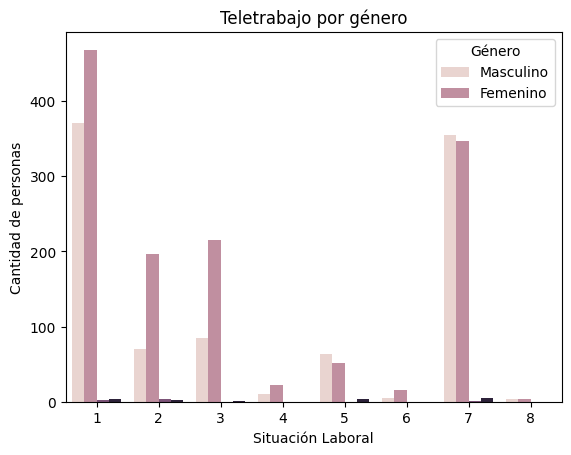

In [70]:
sns.countplot(data=df, x='TELE_TRA', hue='GEN')
plt.title('Teletrabajo por género')
plt.xlabel('Situación Laboral')
plt.ylabel('Cantidad de personas')
plt.legend(title='Género', labels=['Masculino', 'Femenino'])
plt.show()


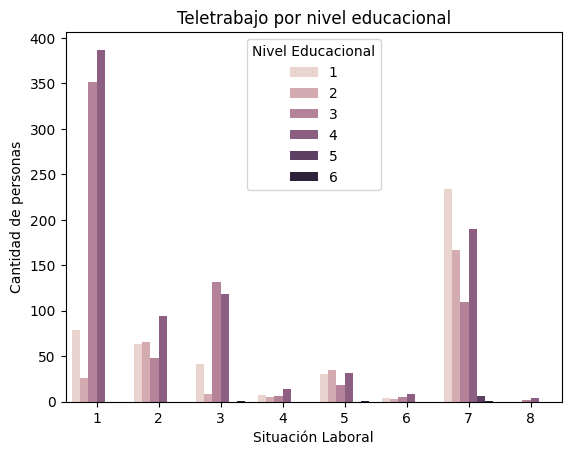

In [72]:
sns.countplot(data=df, x='TELE_TRA', hue='NIVEL_EDUC')
plt.title('Teletrabajo por nivel educacional')
plt.xlabel('Situación Laboral')
plt.ylabel('Cantidad de personas')
plt.legend(title='Nivel Educacional')
plt.show()


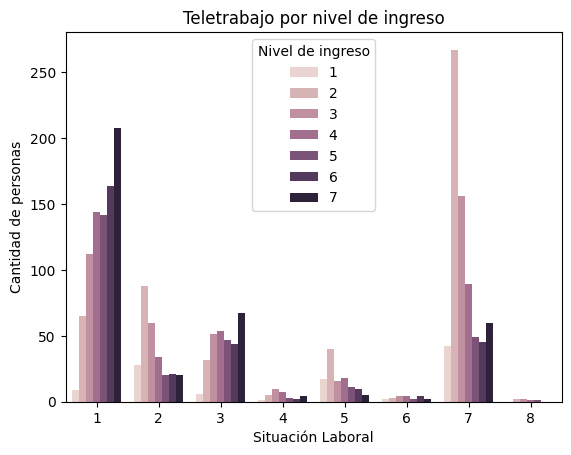

In [73]:
sns.countplot(data=df, x='TELE_TRA', hue='INGRESO')
plt.title('Teletrabajo por nivel de ingreso')
plt.xlabel('Situación Laboral')
plt.ylabel('Cantidad de personas')
plt.legend(title='Nivel de ingreso')
plt.show()


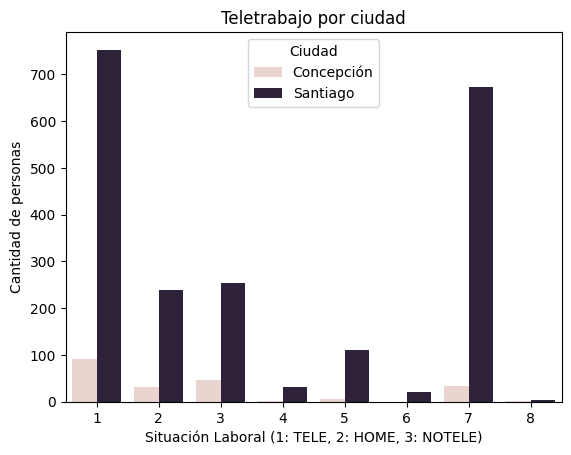

In [69]:
sns.countplot(data=df, x='TELE_TRA', hue='CIUDAD')
plt.title('Teletrabajo por ciudad')
plt.xlabel('Situación Laboral (1: TELE, 2: HOME, 3: NOTELE)')
plt.ylabel('Cantidad de personas')
plt.legend(title='Ciudad', labels=['Concepción', 'Santiago'])
plt.show()
